# PCA on Sector ETFs with Bootstrap Loading Stability

**Docker image**: `ml4t`

**Chapter 14: Latent Factors**
**Section Reference**: See Section 14.2 for PCA theory and Section 14.3 for eigenportfolios

## Purpose
This notebook applies PCA to sector ETFs to extract latent risk factors and quantifies
loading stability using bootstrap resampling. We demonstrate how PCA captures market
and rotation factors, and how to assess whether factor loadings are statistically reliable.

## Where this fits in the framework

PCA is the simplest realisation of **Stage 1** in the two-step latent-factor
framework (Figure 14.9): it compresses an $(T \times N)$ returns panel to
a $(T \times K)$ factor history via SVD. This notebook focuses on the
Stage 1 outputs — variance decomposition, loadings, bootstrap stability —
and the structural interpretation of the principal components. The full
Stage 1 + 2 + 3 pipeline (with a Stage 2 forecaster turning factor history
into asset signals) is exercised in [`04_ipca`](04_ipca.ipynb) and
[`05_rp_pca`](05_rp_pca.ipynb).

## Learning Objectives
- LO1: Apply PCA to sector ETF returns and interpret variance decomposition
- LO2: Quantify loading stability with bootstrap confidence intervals
- LO3: Interpret sector factor exposures (market vs rotation)
- LO4: Analyze temporal stability of factor structure using rolling PCA

## Cross-References
- **Upstream**: Chapter 3 (ETF data loading)
- **Downstream**: Chapter 16 (factor investing), Chapter 18 (factor-based backtesting)
- **Related**: [`02_eigenportfolios`](02_eigenportfolios.ipynb) (stock-level PCA), Section 9.4 (HMM regimes)

## Data Source
ETF Universe parquet (canonical data, no API calls)

**Prerequisites**: Requires ETF Universe data (see Chapter 3).

## 1. Setup and Imports

In [1]:
"""PCA on Sector ETFs — Variance decomposition and bootstrap loading stability."""

import warnings
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
# Production defaults (Papermill overrides for CI testing)
START_DATE = "2010-01-01"
END_DATE = "2024-12-01"
N_BOOTSTRAP = 100
SEED = 42

In [3]:
# Configuration
set_global_seeds(SEED)
rng = np.random.default_rng(SEED)

# Sector ETFs available in ETF Universe parquet (9 of 11 GICS sectors)
# Note: XLC (Communication Services) and XLRE (Real Estate) are newer ETFs
# not included in the canonical dataset
SECTOR_ETFS = {
    "XLB": "Materials",
    "XLE": "Energy",
    "XLF": "Financials",
    "XLI": "Industrials",
    "XLK": "Technology",
    "XLP": "Staples",
    "XLU": "Utilities",
    "XLV": "Healthcare",
    "XLY": "Discretionary",
}

print(
    f"PCA Sector: {len(SECTOR_ETFS)} ETFs, {START_DATE} to {END_DATE}, {N_BOOTSTRAP} bootstrap samples"
)

PCA Sector: 9 ETFs, 2010-01-01 to 2024-12-01, 100 bootstrap samples


## 2. Load Sector ETF Data

Load sector ETFs from the canonical ETF Universe parquet file.

In [4]:
etf_data = load_etfs()

# Filter to sector ETFs and date range
tickers = list(SECTOR_ETFS.keys())
start_dt = date.fromisoformat(START_DATE)
end_dt = date.fromisoformat(END_DATE)
sector_data = (
    etf_data.filter(pl.col("symbol").is_in(tickers))
    .filter(pl.col("timestamp") >= start_dt)
    .filter(pl.col("timestamp") <= end_dt)
    .select(["timestamp", "symbol", "close"])
    .sort(["timestamp", "symbol"])
)

# Pivot to wide format
prices = (
    sector_data.pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
    .to_pandas()
    .set_index("timestamp")
)

# Ensure column order matches SECTOR_ETFS
prices = prices[[t for t in tickers if t in prices.columns]]

# Clean data
prices = prices.dropna(how="all").ffill()

# Calculate returns
returns = prices.pct_change().dropna()
print(
    f"Loaded: {prices.shape[0]} days, {prices.shape[1]} sectors, {returns.shape[0]} return observations"
)

Loaded: 3753 days, 9 sectors, 3752 return observations


Quick summary of the return distributions before PCA — important because PCA is sensitive
to outliers and non-normality.

In [5]:
returns.describe().round(4)

,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
count,3752.0000,3752.0000,3752.0000,3752.0000,3752.0000,3752.0000,3752.0000,3752.0000,3752.0000
mean,0.0004,0.0004,0.0006,0.0006,0.0008,0.0004,0.0005,0.0005,0.0007
std,0.0132,0.0173,0.0140,0.0123,0.0134,0.0086,0.0111,0.0101,0.0126
min,-0.1101,-0.2014,-0.1371,-0.1134,-0.1381,-0.0940,-0.1136,-0.0986,-0.1267
25%,-0.0062,-0.0077,-0.0059,-0.0050,-0.0052,-0.0036,-0.0051,-0.0042,-0.0050
50%,0.0008,0.0005,0.0008,0.0009,0.0011,0.0007,0.0009,0.0008,0.0013
75%,0.0075,0.0087,0.0075,0.0066,0.0073,0.0050,0.0062,0.0059,0.0072
max,0.1176,0.1604,0.1316,0.1265,0.1173,0.0851,0.1279,0.0771,0.0938


## 3. PCA on Sector Returns

We use **correlation-PCA** (standardized returns) rather than covariance-PCA. Standardizing
to unit variance prevents high-volatility sectors (e.g., Energy) from dominating the first
component. For cross-sectional equity analysis this is the standard choice — see the Scale
Sensitivity discussion in Section 14.2.

PCA decomposes the covariance matrix as:

$$\Sigma = V \Lambda V^T$$

where $V$ contains eigenvectors (loadings) and $\Lambda$ is the diagonal matrix of
eigenvalues.

In [6]:
# Standardize returns (correlation-PCA)
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)

# Fit PCA — default solver is appropriate for small N (9 sectors);
# use svd_solver='randomized' for N > 500
n_components = min(len(SECTOR_ETFS), 5)
pca = PCA(n_components=n_components)
factors = pca.fit_transform(returns_scaled)

# Create factor DataFrame
factor_cols = [f"PC{i + 1}" for i in range(n_components)]
factors_df = pd.DataFrame(factors, index=returns.index, columns=factor_cols)

### Variance Decomposition

The fraction of total variance explained by component $k$ is:

$$\text{VE}_k = \frac{\lambda_k}{\sum_{i=1}^{N} \lambda_i}$$

In [7]:
cum_var = np.cumsum(pca.explained_variance_ratio_)
variance_df = pd.DataFrame(
    {
        "Component": factor_cols,
        "Var Explained": pca.explained_variance_ratio_,
        "Cumulative": cum_var,
    }
).set_index("Component")

variance_df.style.format({"Var Explained": "{:.2%}", "Cumulative": "{:.2%}"})

,Var Explained,Cumulative
Component,,
PC1,71.13%,71.13%
PC2,9.03%,80.16%
PC3,6.65%,86.81%
PC4,3.44%,90.25%
PC5,2.77%,93.02%


### Scree Plot

The scree plot (Figure 14.2 in the text) shows eigenvalues in descending order. The
"elbow" where explained variance levels off suggests how many components to retain.

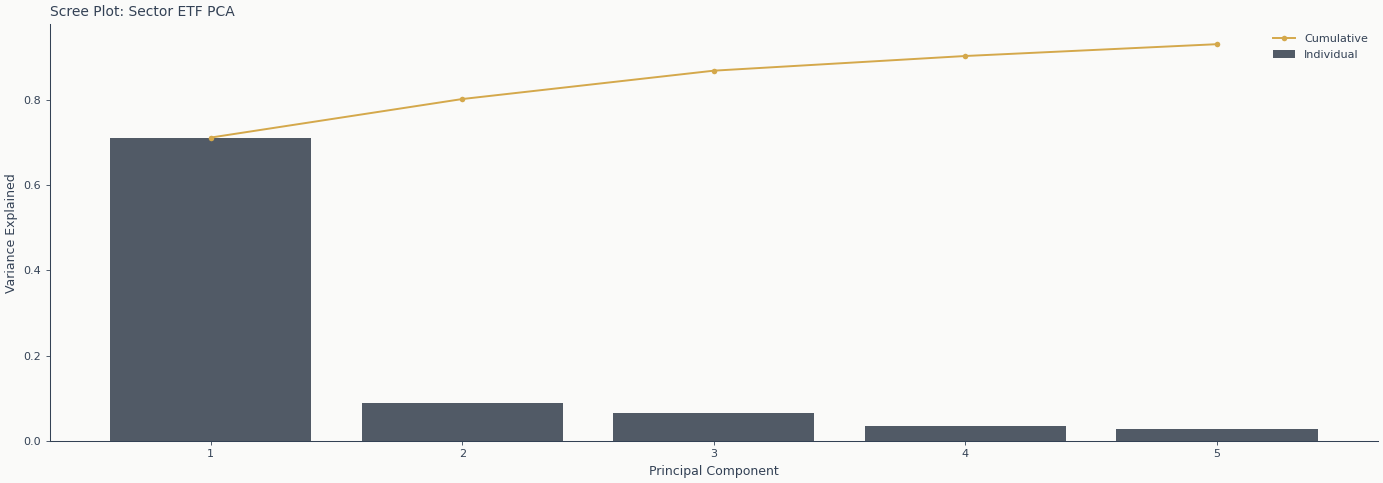

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

# Bar chart of individual variance shares
ax.bar(
    range(1, n_components + 1),
    pca.explained_variance_ratio_,
    alpha=0.7,
    label="Individual",
)

# Cumulative line on same axis
ax.plot(
    range(1, n_components + 1),
    cum_var,
    "o-",
    color="C1",
    label="Cumulative",
)

ax.set_xlabel("Principal Component")
ax.set_ylabel("Variance Explained")
ax.set_title("Scree Plot: Sector ETF PCA")
ax.set_xticks(range(1, n_components + 1))
ax.legend()
fig.tight_layout()
fig.show()

In [9]:
# Persist the scree decomposition so Figure 14.2 can be re-rendered at print
# resolution without re-fitting the PCA. Saved as a portable .npz alongside the
# notebook's other PCA outputs.
artifact_dir = Path("output/pca_equity_sectors")
artifact_dir.mkdir(parents=True, exist_ok=True)
np.savez(
    artifact_dir / "scree.npz",
    explained_variance_ratio=pca.explained_variance_ratio_,
    cumulative_variance=cum_var,
    n_components=np.asarray(n_components),
)

**Finding**: The first two components capture about 80% of total variance. PC1 (the
market factor) dominates at ~71%, with diminishing returns beyond PC3. This steep drop-off
is typical for sector ETFs, where broad market risk accounts for most co-movement.

## 4. Loadings Interpretation

Each eigenvector defines a principal component as a linear combination of sector returns.
The loadings can be interpreted as portfolio weights.

In [10]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=returns.columns,
    columns=factor_cols,
)
loadings["Sector"] = loadings.index.map(SECTOR_ETFS)
loadings.set_index("Sector")[["PC1", "PC2", "PC3"]]

,PC1,PC2,PC3
Sector,,,
Materials,0.358794,-0.192435,0.128017
Energy,0.293976,-0.388716,0.625226
Financials,0.354899,-0.200331,0.114762
Industrials,0.371567,-0.153220,0.055288
Technology,0.335111,-0.102950,-0.514591
Staples,0.322143,0.469347,-0.005122
Utilities,0.267512,0.683790,0.328891
Healthcare,0.336898,0.175881,-0.186308
Discretionary,0.345964,-0.137374,-0.410812


**Interpretation**: PC1 loadings are uniformly positive — the classic "market factor" where
all sectors move together. PC2 separates defensive sectors (positive loadings: Utilities,
Staples) from cyclical sectors (negative loadings: Energy, Financials, Discretionary),
capturing the sector rotation dimension.

## 5. Bootstrap Loading Stability

Are the loadings statistically reliable, or could they be estimation noise? We use bootstrap
resampling to construct 95% confidence intervals. The default `N_BOOTSTRAP=100` provides
a reasonable speed-vs-precision tradeoff; increase to 1,000+ for publication-quality intervals.

### Sign Alignment for PCA Components

PCA signs are arbitrary — successive fits may flip component directions. We align
to a reference set so loadings are comparable across bootstrap samples.

In [11]:
def align_signs(loadings_new: np.ndarray, reference: np.ndarray) -> np.ndarray:
    """Align PCA loading signs with a reference to handle sign indeterminacy.

    PCA eigenvectors are defined only up to sign — this helper flips components
    to maintain consistent orientation across bootstrap samples or rolling windows.
    """
    aligned = loadings_new.copy()
    n_components = aligned.shape[1] if aligned.ndim == 2 else aligned.shape[0]
    for j in range(n_components):
        vec = aligned[:, j] if aligned.ndim == 2 else aligned[j]
        ref = reference[:, j] if reference.ndim == 2 else reference[j]
        if np.corrcoef(vec, ref)[0, 1] < 0:
            if aligned.ndim == 2:
                aligned[:, j] *= -1
            else:
                aligned[j] *= -1
    return aligned

### Bootstrap Confidence Intervals

Resample returns with replacement and re-estimate PCA to build confidence bands
around eigenvalue magnitudes and loading patterns.

In [12]:
def bootstrap_pca(
    returns_df: pd.DataFrame,
    reference_components: np.ndarray,
    n_bootstrap: int = 100,
    n_components: int = 2,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """Run bootstrap PCA to estimate loading confidence intervals."""
    if rng is None:
        rng = np.random.default_rng()
    n_obs = len(returns_df)
    n_features = returns_df.shape[1]
    bootstrap_loadings = np.zeros((n_bootstrap, n_features, n_components))

    for b in range(n_bootstrap):
        idx = rng.choice(n_obs, size=n_obs, replace=True)
        sample = returns_df.iloc[idx]

        sample_scaled = StandardScaler().fit_transform(sample)
        pca_boot = PCA(n_components=n_components)
        pca_boot.fit(sample_scaled)

        # Align signs with full-sample reference
        loadings_boot = pca_boot.components_.T
        bootstrap_loadings[b] = align_signs(loadings_boot, reference_components.T)

    return bootstrap_loadings

In [13]:
bootstrap_results = bootstrap_pca(
    returns, reference_components=pca.components_, n_bootstrap=N_BOOTSTRAP, n_components=2, rng=rng
)

# Confidence intervals
loading_mean = bootstrap_results.mean(axis=0)
loading_std = bootstrap_results.std(axis=0)
loading_lower = np.percentile(bootstrap_results, 2.5, axis=0)
loading_upper = np.percentile(bootstrap_results, 97.5, axis=0)

stability_df = pd.DataFrame(
    {
        "Sector": [SECTOR_ETFS.get(t, t) for t in returns.columns],
        "PC1 Mean": loading_mean[:, 0],
        "PC1 CI Width": loading_upper[:, 0] - loading_lower[:, 0],
        "PC2 Mean": loading_mean[:, 1],
        "PC2 CI Width": loading_upper[:, 1] - loading_lower[:, 1],
    }
).set_index("Sector")

stability_df.style.format("{:.3f}")

,PC1 Mean,PC1 CI Width,PC2 Mean,PC2 CI Width
Sector,,,,
Materials,0.359,0.007,-0.189,0.046
Energy,0.295,0.016,-0.380,0.168
Financials,0.355,0.006,-0.199,0.061
Industrials,0.372,0.009,-0.154,0.044
Technology,0.335,0.008,-0.111,0.152
Staples,0.322,0.008,0.467,0.043
Utilities,0.267,0.024,0.685,0.097
Healthcare,0.337,0.009,0.178,0.082
Discretionary,0.346,0.008,-0.140,0.115


Sectors with narrow CI widths have statistically stable loadings; wide intervals suggest
the loading is sensitive to the particular sample and should be interpreted cautiously.

## 6. Visualization: Loading Confidence Intervals

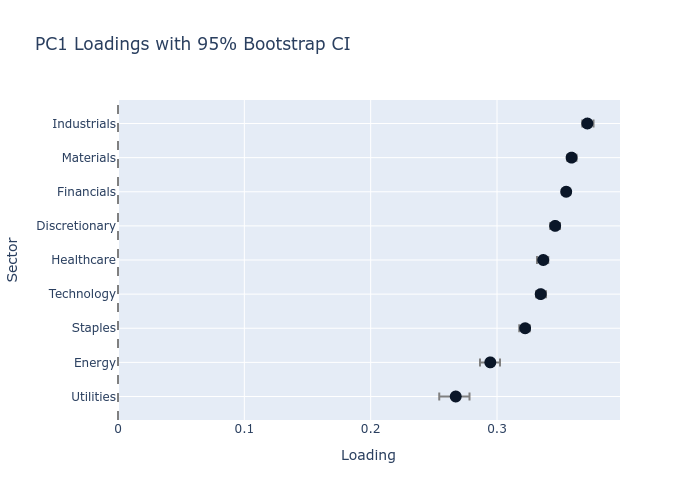

In [14]:
# Plot PC1 loadings with bootstrap CIs
fig = go.Figure()

order = loading_mean[:, 0].argsort()
sectors_sorted = [returns.columns[i] for i in order]
sector_names = [SECTOR_ETFS.get(s, s) for s in sectors_sorted]

fig.add_trace(
    go.Scatter(
        x=[loading_mean[i, 0] for i in order],
        y=sector_names,
        mode="markers",
        marker=dict(size=12, color=COLORS["blue"]),
        error_x=dict(
            type="data",
            symmetric=False,
            array=[(loading_upper[i, 0] - loading_mean[i, 0]) for i in order],
            arrayminus=[(loading_mean[i, 0] - loading_lower[i, 0]) for i in order],
            color="gray",
            thickness=2,
        ),
        name="PC1 Loading",
    )
)

fig.add_vline(x=0, line_dash="dash", line_color="gray")
fig.update_layout(
    title="PC1 Loadings with 95% Bootstrap CI",
    xaxis_title="Loading",
    yaxis_title="Sector",
    height=500,
)
fig.show()

**Finding**: All sectors load positively on PC1, confirming its role as the market factor.
Most sectors have tight CIs (width < 0.01), indicating very stable market exposures.
Utilities (0.024) and Energy (0.016) show the widest intervals, suggesting their market
beta estimates are less precise and warrant caution in portfolio construction.

## 7. Temporal Stability: Rolling PCA

Factor structure is not constant — correlations spike during crises (increasing PC1
variance) and relax in calm markets. Rolling-window PCA tracks this evolution.

**Methodological note**: We align each window's loadings with the *previous* window to
maintain visual continuity. For long time series, this sequential alignment can accumulate
drift; an alternative is aligning all windows to the full-sample loadings.

In [15]:
window = 252  # 1-year rolling window

rolling_loadings = []
rolling_var_explained = []

for i in range(window, len(returns)):
    window_returns = returns.iloc[i - window : i]

    scaled = StandardScaler().fit_transform(window_returns)
    pca_roll = PCA(n_components=2)
    pca_roll.fit(scaled)

    loadings_roll = pca_roll.components_.copy()
    if len(rolling_loadings) > 0:
        loadings_roll = align_signs(loadings_roll, rolling_loadings[-1])

    rolling_loadings.append(loadings_roll)
    rolling_var_explained.append(pca_roll.explained_variance_ratio_)

rolling_loadings = np.array(rolling_loadings)
rolling_var_explained = np.array(rolling_var_explained)

roll_dates = returns.index[window:]

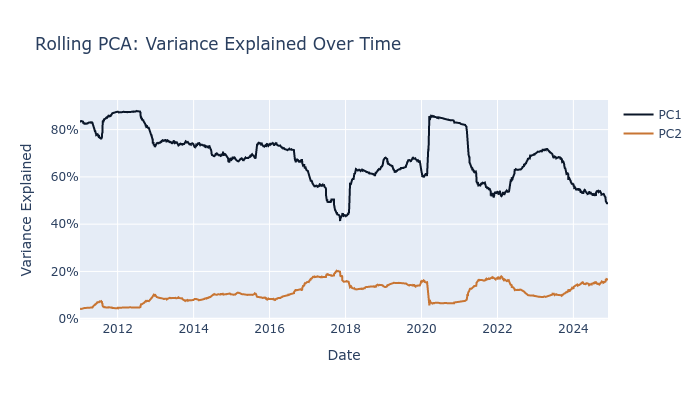

In [16]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=roll_dates, y=rolling_var_explained[:, 0], name="PC1", line=dict(color=COLORS["blue"])
    )
)
fig.add_trace(
    go.Scatter(
        x=roll_dates, y=rolling_var_explained[:, 1], name="PC2", line=dict(color=COLORS["copper"])
    )
)
fig.update_layout(
    title="Rolling PCA: Variance Explained Over Time",
    xaxis_title="Date",
    yaxis_title="Variance Explained",
    yaxis_tickformat=".0%",
    height=400,
)
fig.show()

**Finding**: PC1 variance share spikes during market stress (COVID-19 in 2020, rate
shocks in 2022) when cross-sector correlations increase — the classic "correlations go
to 1 in a crisis" effect. During calm periods, PC1 explains less and PC2 (sector rotation)
gains relative importance.

In [17]:
print(f"Rolling window: {window} days")
print(
    f"PC1 variance range: {rolling_var_explained[:, 0].min():.1%} – {rolling_var_explained[:, 0].max():.1%}"
)
print(
    f"PC2 variance range: {rolling_var_explained[:, 1].min():.1%} – {rolling_var_explained[:, 1].max():.1%}"
)

Rolling window: 252 days
PC1 variance range: 41.5% – 87.9%
PC2 variance range: 4.1% – 20.3%


## 8. Factor Score Analysis

PC scores from correlation-PCA are mean-zero standardized projections — they cannot be
compounded as portfolio returns because PCA centers the input. What they *can* do is
expose the cross-sectional structure each component captures. We rescale all PC scores by
a single constant so PC1's daily standard deviation matches the equal-weight sector
portfolio; this preserves the eigenvalue hierarchy ($\sigma_{\text{PC2}}/\sigma_{\text{PC1}} =
\sqrt{\lambda_2/\lambda_1}$) while putting PC1 on the same daily scale as the broad market.

In [18]:
ew_daily_std = returns.mean(axis=1).std()
score_scale = ew_daily_std / factors_df["PC1"].std()
factor_returns = factors_df * score_scale

factor_stats = pd.DataFrame(
    {
        "Daily Std": factor_returns.std(),
        "Ann Std": factor_returns.std() * np.sqrt(252),
        "Skew": factor_returns.skew(),
        "Kurt": factor_returns.kurtosis(),
    }
)

factor_stats.style.format(
    {"Daily Std": "{:.4f}", "Ann Std": "{:.2%}", "Skew": "{:.2f}", "Kurt": "{:.2f}"}
)

,Daily Std,Ann Std,Skew,Kurt
PC1,0.0105,16.70%,-0.51,14.42
PC2,0.0037,5.95%,-0.01,8.75
PC3,0.0032,5.11%,0.24,4.74
PC4,0.0023,3.67%,-0.10,2.03
PC5,0.0021,3.29%,-0.04,2.64


Daily volatility falls off rapidly past PC1 — PC2 carries roughly $\sqrt{\lambda_2/\lambda_1}
\approx 36\%$ of PC1's variance, and tail components are below 25%. This matches the
eigenvalue decline reported in the variance table above.

Prepare two diagnostic series: PC1 vs the equal-weight market (both standardized to unit
variance so the scatter slope is the correlation), and the rolling 63-day PC1-PC2
correlation (in-sample orthogonality means the long-run mean is zero by construction).

In [19]:
ew_returns = returns.mean(axis=1)
pc1_z = (factor_returns["PC1"] - factor_returns["PC1"].mean()) / factor_returns["PC1"].std()
ew_z = (ew_returns - ew_returns.mean()) / ew_returns.std()
roll_corr = factor_returns["PC1"].rolling(63).corr(factor_returns["PC2"])

Build the two-panel subplot grid: scatter on the left, time series on the right.

In [20]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "PC1 vs Equal-Weight Market (standardized)",
        "Rolling 63d PC1-PC2 Correlation",
    ),
    column_widths=[0.45, 0.55],
    horizontal_spacing=0.15,
)

Add the scatter, 45° reference line, and rolling-correlation traces to the grid.

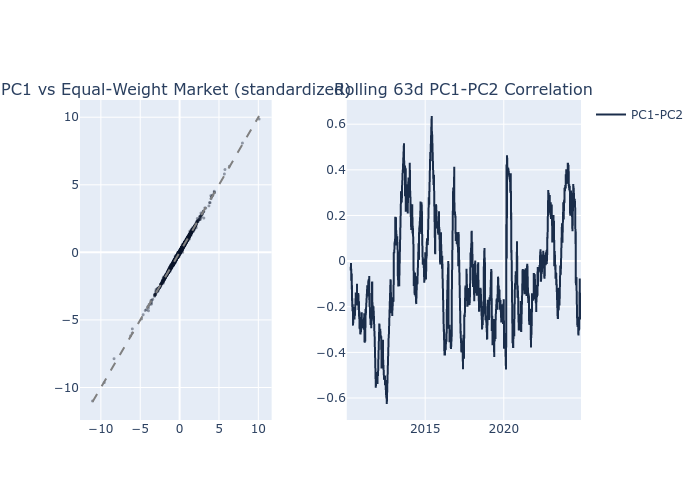

In [21]:
fig.add_trace(
    go.Scatter(
        x=ew_z,
        y=pc1_z,
        mode="markers",
        marker=dict(size=3, color=COLORS["blue"], opacity=0.4),
        name="Daily",
        showlegend=False,
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=[ew_z.min(), ew_z.max()],
        y=[ew_z.min(), ew_z.max()],
        mode="lines",
        line=dict(color="gray", dash="dash"),
        name="45°",
        showlegend=False,
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(x=roll_corr.index, y=roll_corr, line=dict(color=COLORS["slate"]), name="PC1-PC2"),
    row=1,
    col=2,
)

Apply axis labels and layout, render, and report the headline correlation statistics.

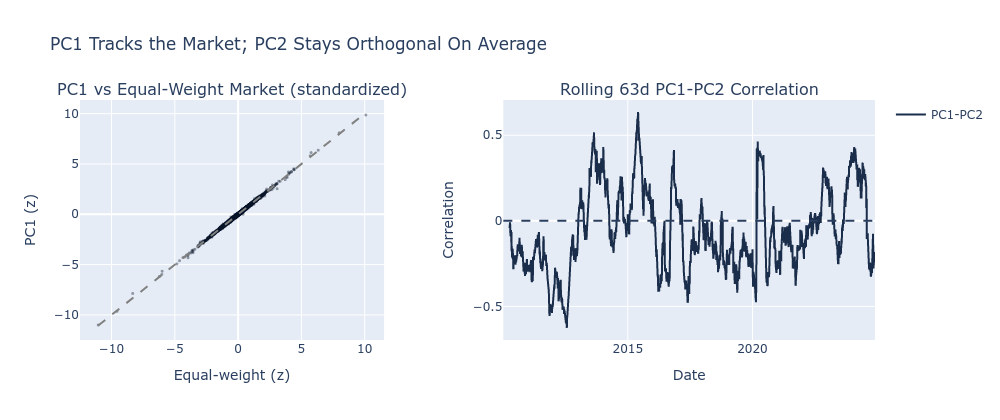

PC1 vs equal-weight daily correlation: 0.9983
Rolling 63d PC1-PC2 correlation: mean=-0.062, std=0.238


In [22]:
fig.add_hline(y=0, line_dash="dash", row=1, col=2)
fig.update_xaxes(title_text="Equal-weight (z)", row=1, col=1)
fig.update_yaxes(title_text="PC1 (z)", row=1, col=1)
fig.update_xaxes(title_text="Date", row=1, col=2)
fig.update_yaxes(title_text="Correlation", row=1, col=2)
fig.update_layout(
    height=420,
    width=1000,
    title_text="PC1 Tracks the Market; PC2 Stays Orthogonal On Average",
)
fig.show()

pc1_market_corr = factor_returns["PC1"].corr(ew_returns)
print(f"PC1 vs equal-weight daily correlation: {pc1_market_corr:.4f}")
print(f"Rolling 63d PC1-PC2 correlation: mean={roll_corr.mean():+.3f}, std={roll_corr.std():.3f}")

**Finding**: PC1's daily score correlates above 0.99 with the equal-weight sector portfolio —
PC1 *is* the broad market in this universe, up to centering. The rolling PC1–PC2 correlation
fluctuates around zero with non-trivial variance: the in-sample orthogonality constraint
holds globally but short-window deviations are substantial, particularly during regime
transitions. This is why orthogonality must be re-imposed in production by refitting on
expanding or rolling windows rather than relying on a single in-sample decomposition.

## 9. Sector Rotation Signal

As a preview of eigenportfolio applications (developed fully in Section 14.3 and
[`02_eigenportfolios`](02_eigenportfolios.ipynb)), we construct a simple long-short rotation signal from PC2
loadings. PC2 typically captures cyclical-vs-defensive rotation.

In [23]:
# Construct rotation positions from PC2 loadings
pc2_loadings = loadings["PC2"]
pc2_signal = factors_df["PC2"]

rotation_positions = pd.DataFrame(index=returns.index, columns=returns.columns)
for sector in returns.columns:
    rotation_positions[sector] = np.sign(pc2_loadings[sector]) * pc2_signal

# Normalize to zero-mean cross-section (long-short)
rotation_positions = rotation_positions.sub(rotation_positions.mean(axis=1), axis=0)

In [24]:
# Evaluate rotation strategy vs equal-weight benchmark
rotation_returns = (rotation_positions.shift(1) * returns).sum(axis=1)
equal_weight_returns = returns.mean(axis=1)

strategy_comparison = pd.DataFrame(
    {
        "Ann Return": [r.mean() * 252 for r in [equal_weight_returns, rotation_returns]],
        "Ann Vol": [r.std() * np.sqrt(252) for r in [equal_weight_returns, rotation_returns]],
        "Sharpe": [
            r.mean() / r.std() * np.sqrt(252) for r in [equal_weight_returns, rotation_returns]
        ],
    },
    index=["Equal Weight", "PC2 Rotation"],
)

strategy_comparison.style.format({"Ann Return": "{:.2%}", "Ann Vol": "{:.2%}", "Sharpe": "{:.2f}"})

,Ann Return,Ann Vol,Sharpe
Equal Weight,13.59%,16.70%,0.81
PC2 Rotation,50.14%,78.69%,0.64


**Interpretation**: The PC2 rotation signal produces a positive but lower Sharpe than the
equal-weight benchmark, at roughly five times the volatility — the unbounded position scale
(driven by the daily PC2 score magnitude) inflates both ends of the table without improving
risk-adjusted return. On a narrow universe of nine sectors, this kind of single-factor
long-short demo is informative about the rotation dimension PC2 captures, not a
competitive alpha source. Section 14.3 develops eigenportfolio construction more rigorously
on broader universes with proper position sizing.

## Key Takeaways

1. **Dominant market factor**: PC1 captures ~71% of sector ETF variance — all sectors
   load positively, reflecting broad market risk
2. **Bootstrap stability matters**: Not all loadings are equally reliable. Sectors with
   wide confidence intervals (e.g., Utilities, Energy) warrant caution in portfolio construction
3. **Time-varying structure**: Rolling PCA reveals that PC1 variance spikes during crises
   (correlations increase) and declines in calm markets — relevant for regime-conditional
   strategies
4. **Rotation signal is modest**: PC2-based sector rotation produces a low Sharpe on 9
   ETFs; the insight is structural (identifying the rotation dimension) rather than
   directly profitable

### PCA in the Two-Step Framework

Everything above is **Stage 1**. To turn it into a return forecast, a
Stage 2 factor-premium forecaster is required (see Figure 14.10 for the
full catalog). PCA + sample-mean Stage 2 collapses to a per-asset
historical-mean predictor — a useful sanity-check baseline but not a
forecaster in any meaningful sense. Non-trivial cross-sectional ranking
emerges only when Stage 2 conditions on the factor path (AR(1), EWMA, or
richer ML forecasters). The IPCA notebook demonstrates the full pipeline
end-to-end.

**Next Steps**:
- For eigenportfolio construction on a broader stock universe, see [`02_eigenportfolios`](02_eigenportfolios.ipynb)
- For Stage 1 + 2 + 3 end-to-end with characteristic-driven loadings, see [`04_ipca`](04_ipca.ipynb)
- For production PCA with walk-forward CV on ETFs, see [`11_latent_factors`](../case_studies/etfs/11_latent_factors.ipynb)